# Predicting Online Purchase Intention Using a Deep Neural Network

## 1. Business Problem

An ecommerce firm desires to foresee whether an online browsing session will be converted into a buy. This accuracy can enable the firm to recognize high-value sessions, enhance focused marketing efforts and inform customer strategies towards conversion.

The problem is seen as a binary classification problem. Classified variable is the classification of the target variable, e.g., True means that the customer purchased a product, and False means he did not purchase a product.

Since there is tabular structured information about the customers' sessions, a feed-forward Multilayer Perceptron (MLP) neural network is created using TensorFlow/Keras (Ma *et al* 2024). Because of the tabular structured information about the customers' sessions, a feed-forward Multilayer Perceptron (MLP) neural network is built using TensorFlow/Keras. Data Exploration, Data Preprocessing, Feature Engineering, Neural Network experimentation and evaluation on an unseen test set is conducted for the pipeline.

## 2. Objectives

- To design a TensorFlow/Keras Neural Network model for predicting online purchase intention.

- To perform pre-processing of numerical and categorical session variables to enable model training.

- To compare the performance of 10 different neural network models based on validation.

- To analyse the chosen model using metrics such as accuracy, precision, recall, F1-score and confusion matrix.

- To derive useful marketing and target customer strategies for e-commerce based on the model.

## 3. Data Collection Strategy

The dataset used is from the Online Shoppers Purchasing Intention Dataset at UCI Machine Learning Repository, consisting of 12,330 online shopping sessions and 18 attributes. This set of data contains records of browsing behaviour, session attributes, traffic details and visitor attributes, where the variable “Revenue” refers to the purchase action.

## Import libraries and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

np.random.seed(42)
tf.random.set_seed(42)

df = pd.read_csv("online_shoppers_intention.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 4. Data Exploration

It is a data set consisting of 12,330 shopping sessions conducted on-line and 18 variables. The binary response variable is `Revenue` whereas the predictors are describing the browsing activity, the length of browsing time, the traffic characteristics as well as the visitor behaviour.

Data types, missing values and class distribution are initially checked. Class imbalance is significant because purchase sessions make a relatively small contribution to the observations compared to the observations from non-purchase sessions.

In [2]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           


Target distribution:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Target percentage:
Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64


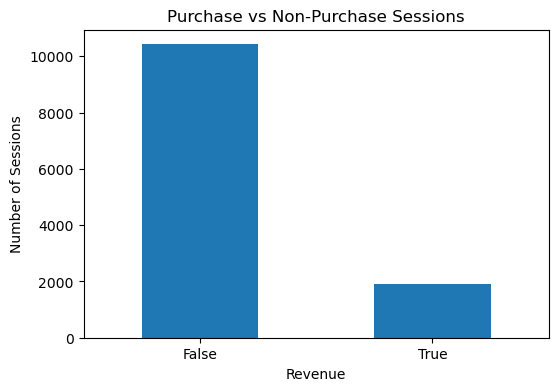

In [3]:
print("\nTarget distribution:")
print(df["Revenue"].value_counts())
print("\nTarget percentage:")
print(df["Revenue"].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(6,4))
df["Revenue"].value_counts().plot(kind="bar")
plt.title("Purchase vs Non-Purchase Sessions")
plt.xlabel("Revenue")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)
plt.show()

There is a large class imbalance in the target distribution. Of 12,330 sessions, 10,422 (84.53%) resulted in no purchase, while only 1,908 (15.47%) generated revenue. Hence, in model evaluation, precision, recall and F1-score should be taken into account in addition to accuracy to prevent the misleading evaluation results.

In [4]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12330.0,NaN,NaN,NaN,2.315166,3.321784,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12330.0,NaN,NaN,NaN,80.818611,176.779107,0.0,0.0,7.5,93.25625,3398.75
Informational,12330.0,NaN,NaN,NaN,0.503569,1.270156,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12330.0,NaN,NaN,NaN,34.472398,140.749294,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12330.0,NaN,NaN,NaN,31.731468,44.475503,0.0,7.0,18.0,38.0,705.0
ProductRelated_Duration,12330.0,NaN,NaN,NaN,1194.74622,1913.669288,0.0,184.1375,598.936905,1464.157214,63973.52223
BounceRates,12330.0,NaN,NaN,NaN,0.022191,0.048488,0.0,0.0,0.003112,0.016813,0.2
ExitRates,12330.0,NaN,NaN,NaN,0.043073,0.048597,0.0,0.014286,0.025156,0.05,0.2
PageValues,12330.0,NaN,NaN,NaN,5.889258,18.568437,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12330.0,NaN,NaN,NaN,0.061427,0.198917,0.0,0.0,0.0,0.0,1.0


## 5. Data Preparation


The target is converted from Boolean values into 0 and 1. Standardizing numeric variables to aid in optimisation of the neural network. 

Any variables whose values represent categories are one-hot encoded before processing, otherwise their numeric codes may be misinterpreted as continuous quantities.

Stratification is used to split the data into training, validation and test set. Test set is not visible until the final test of the model.

In [5]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"].astype(int)

# Variables treated as categorical
cat_cols = [
    "Month", "OperatingSystems", "Browser", "Region",
    "TrafficType", "VisitorType", "Weekend"
]

num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(8631, 17) (1849, 17) (1850, 17)


### Encoding and scaling

In [6]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", encoder, cat_cols)
])

X_train_p = preprocessor.fit_transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

print("Processed training shape:", X_train_p.shape)

Processed training shape: (8631, 75)


## 6. Neural Network Design

The number of pipeline configurations tested by varying key neural-network design choices is 10. These are: hidden-layer size, network depth, dropout, learning rate and batch size.

As the classes for the target variable are imbalanced, validation F1-score is reported along with validation accuracy. The train-validation-test split is consistent across experiments to give a basis for comparison.

### Class weights

In [7]:
classes, counts = np.unique(y_train, return_counts=True)
class_weight = {
    int(c): len(y_train) / (2 * n)
    for c, n in zip(classes, counts)
}
print("Class weights:", class_weight)

Class weights: {0: np.float64(0.5915695681973955), 1: np.float64(3.2301646706586826)}


### MLP function

In [8]:
def build_model(layers, dropout=0.0, lr=0.001):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(X_train_p.shape[1],)))
    
    for units in layers:
        model.add(tf.keras.layers.Dense(units, activation="relu"))
        if dropout > 0:
            model.add(tf.keras.layers.Dropout(dropout))
            
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

## 7. Experimental Evaluation

Ten configurations are illustrated to illustrate the effects of architectural and optimisation decisions on validation performance. 

The configuration that results in the best validation F1-score is chosen as the final candidate since F1 weights precision and recall and fits the unbalanced purchase outcome.

In [11]:
configs = [
    ([16], 0.0, 0.001, 32),
    ([32], 0.0, 0.001, 32),
    ([64], 0.0, 0.001, 32),
    ([32,16], 0.0, 0.001, 32),
    ([64,32], 0.0, 0.001, 32),
    ([32,16], 0.2, 0.001, 32),
    ([64,32], 0.2, 0.001, 32),
    ([64,32], 0.3, 0.001, 32),
    ([64,32], 0.2, 0.0005, 32),
    ([64,32], 0.2, 0.001, 64)
]

results = []

for i, (layers, drop, lr, batch) in enumerate(configs, 1):
    model = build_model(layers, drop, lr)
    
    early = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    )
    
    model.fit(
        X_train_p, y_train,
        validation_data=(X_val_p, y_val),
        epochs=15,
        batch_size=batch,
        class_weight=class_weight,
        callbacks=[early],
        verbose=0
    )
    
    pred = (model.predict(X_val_p, verbose=0).ravel() >= 0.5).astype(int)
    
    results.append({
        "Experiment": i,
        "Architecture": str(layers),
        "Dropout": drop,
        "Learning Rate": lr,
        "Batch Size": batch,
        "Val Accuracy": accuracy_score(y_val, pred),
        "Val Precision": precision_score(y_val, pred, zero_division=0),
        "Val Recall": recall_score(y_val, pred, zero_division=0),
        "Val F1": f1_score(y_val, pred, zero_division=0)
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))

,Experiment,Architecture,Dropout,Learning Rate,Batch Size,Val Accuracy,Val Precision,Val Recall,Val F1
0,1,[16],0.0,0.0010,32,0.8534,0.5173,0.7832,0.6231
1,2,[32],0.0,0.0010,32,0.8513,0.5124,0.7937,0.6228
2,3,[64],0.0,0.0010,32,0.8583,0.5284,0.7797,0.6299
3,4,"[32, 16]",0.0,0.0010,32,0.8502,0.5102,0.7902,0.6200
4,5,"[64, 32]",0.0,0.0010,32,0.8469,0.5033,0.7972,0.6171
5,6,"[32, 16]",0.2,0.0010,32,0.8442,0.4979,0.8112,0.6170
6,7,"[64, 32]",0.2,0.0010,32,0.8540,0.5186,0.7797,0.6229
7,8,"[64, 32]",0.3,0.0010,32,0.8464,0.5022,0.7832,0.6120
8,9,"[64, 32]",0.2,0.0005,32,0.8529,0.5162,0.7797,0.6212
9,10,"[64, 32]",0.2,0.0010,64,0.8534,0.5175,0.7762,0.6210


## 8. Comparison of Validation Results

Ten configurations are illustrated to illustrate the effects of architectural and optimisation decisions on validation performance. 

The configuration that results in the best validation F1-score is chosen as the final candidate since F1 weights precision and recall and fits the unbalanced purchase outcome.

In [12]:
best_row = results_df.loc[results_df["Val F1"].idxmax()]
display(best_row.to_frame().T)

best_layers = eval(best_row["Architecture"])
best_drop = best_row["Dropout"]
best_lr = best_row["Learning Rate"]
best_batch = int(best_row["Batch Size"])

,Experiment,Architecture,Dropout,Learning Rate,Batch Size,Val Accuracy,Val Precision,Val Recall,Val F1
2,3,[64],0.0,0.001,32,0.858302,0.528436,0.77972,0.629944


## 9. Final Model Training

The best configuration found with respect to the validation data is rebuilt and trained with the training set. The idea of early stopping: to stop unnecessary training and prevent overfitting.

The test sets are used only at the end of the experiment for evaluation purposes, and not included in the model selection process.

In [13]:
final_model = build_model(best_layers, best_drop, best_lr)

early = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True
)

history = final_model.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=25,
    batch_size=best_batch,
    class_weight=class_weight,
    callbacks=[early],
    verbose=1
)

Epoch 1/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7590 - loss: 0.4876 - val_accuracy: 0.8426 - val_loss: 0.3947
Epoch 2/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8434 - loss: 0.4043 - val_accuracy: 0.8578 - val_loss: 0.3776
Epoch 3/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8531 - loss: 0.3841 - val_accuracy: 0.8621 - val_loss: 0.3694
Epoch 4/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8574 - loss: 0.3694 - val_accuracy: 0.8610 - val_loss: 0.3608
Epoch 5/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8598 - loss: 0.3566 - val_accuracy: 0.8588 - val_loss: 0.3536
Epoch 6/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8609 - loss: 0.3456 - val_accuracy: 0.8561 - val_loss: 0.3493
Epoch 7/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8626 - loss: 0.3361 - val_accuracy: 0.8572 - val_loss: 0.3458
Epoch 8/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8647 - loss: 0.3282 - val_accuracy: 

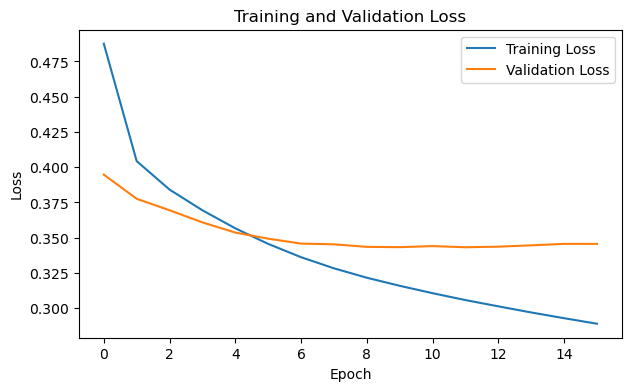

In [14]:
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

The training loss is reduced effectively across the 16 epochs from 0.49 to 0.29, consistently showing reduction in training loss. In start of validations loss is reduced from 0.40 to about 0.34 and remains almost constant and even a bit higher. This implies that there is slight overfitting at about Epoch 8, but not a great deal.

## 10. Final Model Assessment

The final model is tested with a test set [1] that was not part of the model building process. Measure of accuracy is the overall classification correctness, while the measure of precision is the percentage of purchases correctly predicted. Recall is the percentage of actual purchases identified by the model and F1 is a compromise between Recall and Precision.

In [15]:
test_prob = final_model.predict(X_test_p, verbose=0).ravel()
test_pred = (test_prob >= 0.5).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1 Score": f1_score(y_test, test_pred, zero_division=0)
}

metrics_df = pd.DataFrame(
    {"Metric": metrics.keys(), "Score": metrics.values()}
)

display(metrics_df.round(4))
print(classification_report(y_test, test_pred, digits=4))

,Metric,Score
0,Accuracy,0.8632
1,Precision,0.5385
2,Recall,0.8077
3,F1 Score,0.6462


              precision    recall  f1-score   support

           0     0.9613    0.8734    0.9152      1564
           1     0.5385    0.8077    0.6462       286

    accuracy                         0.8632      1850
   macro avg     0.7499    0.8405    0.7807      1850
weighted avg     0.8959    0.8632    0.8736      1850



The model achieves 86.32% accuracy, with 53.85% precision, 80.77% recall, and an F1-score of 64.62%. The high Recall shows the model recognizes the vast majority of real-time purchasing sessions, although the comparatively low Precision means that there is some false positive are being predicted. Thus the model focuses on identifying purchasers rather than in predicting a preciseness level.

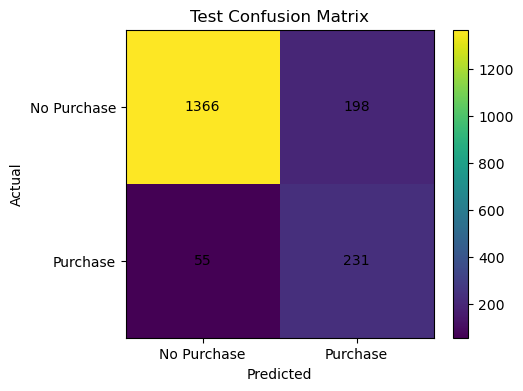

Confusion Matrix:
 [[1366  198]
 [  55  231]]


In [16]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["No Purchase","Purchase"])
plt.yticks([0,1], ["No Purchase","Purchase"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.colorbar()
plt.show()

print("Confusion Matrix:\n", cm)

The confusion matrix presents a performance with 1,366 true negative (TN) and 231 true positive (TP) points that demonstrate both good class performance as well as good classification results. The model has 198 false positives and 55 false negatives. The number of false-negatives is actually low to make the recall 80.77%, which means a lot of the actual purchase sessions are being found.

## 11. Why This is Important

Online purchase intention prediction is necessary since e-commerce firms have to recognize the sessions that have an intention for conversion. According to the provided dataset, the share of sessions that have converted to purchases amounted to only 15.47%, whereas non-conversion sessions were 84.53%. Predictive power can help to implement targeted promotional activities, provide personalized recommendations and optimize marketing budget expenditure.

## 12. How This Solution Works

The prediction approach works in such a way that browsing and session features pass through the TensorFlow/Keras Multilayer Perceptron (MLP). Numerical features get standardization treatment, and categorical features receive one-hot encoding. The hidden layers capture the nonlinear patterns while the sigmoid activation function gives the probability of a purchase.

## 13. Business Interpretation

This neural network has practical application in predicting an e-commerce purchase, yielding an accuracy of **86.32%**, a recall of **80.77%** and an F1 score of **64.62%** on unseen test data. The **53.85% precision** reveals that, out of all the sessions predicted, half were accurately identified which suggests inefficiency in targeting. A confusion matrix is created with 231 true purchases and 55 missed purchases, showing good identification of purchasing customers (Xiong, 2024). On the other hand, 198 non-purchasing sessions were mistakenly identified as purchases resulting in a possible increase in unneeded promotional spending. The model can therefore be useful in upcoming business analytics applications such as targeted promotions, personalised recommendations, and marketing-resource allocation, especially when it's essential to target potential purchasers and not just false-positive ones. The results further indicate why accuracy should be coupled with recall, precision and F1-score for evaluating the model for operational decision making.

## 14. Strengths, Limitations and Deployment

### Strengths
- Understands non-linear relationships between characteristics of sessions.
- Processes several numerical and categorical predictors after processing.
- Makes predictions based on probability.
- Supports extended framework for future prediction of customer sessions.


### Limitations
- The purchase outcome is imbalanced.
- Unlike simpler statistical models, neural networks are not easily interpretable.
- The results will vary with the quality and representativeness of previous sessions.
- The likelihood that future predictive performance will be reduced is influenced by changes in customer behaviour.


### Deployment Consideration

The model could be used as a prediction system that would be accessible for use within an eCommerce platform. A new session would be required to go through the same preprocessing and the neural network would respond with a probability of sale. Monitoring would be required in order to detect any drift in data and loss of model performance.

## 15. Conclusion

This project aimed at building an end-to-end Deep Learning pipeline which has been used for predicting consumers' behavioral intention to purchase online products and services. The steps taken were exploratory analysis, encoding the data in categories, normalization of numerical data, stratified data split, modelling with neural networks from the TensorFlow/Keras libraries, and systematic experiments with ten different network configurations.

Final architecture was chosen based on the validation performance and then related to an unseen test set. The results show that the online-session information can be effectively turned into a predictive system using a neural-network approach that could be used to inform data-driven e-commerce decisions.

# References

Xiong, Q., 2024, December. Deep learning in predicting consumer purchase intentions. In *Proceedings of the 3rd International Conference on Signal Processing, Computer Networks and Communications* (pp. 525–530).

Ma, X., Li, Y. and Asif, M., 2024. E-commerce review sentiment analysis and purchase intention prediction based on deep learning technology. *Journal of Organizational and End User Computing (JOEUC)*, 36(1), pp.1–29.

## Dataset Link: https://archive.ics.uci.edu/dataset/468/online%2Bshoppers%2Bpurchasing%2Bintention%2Bdatase